# Pre-trained Encoder + JacobianODE — Lorenz (Loop Closure Sweep)

This notebook sweeps over **loop closure weight** values for the JacobianODE
trained on a pre-trained encoder's latent space.

**Pipeline:**
1. Load pre-trained encoder config from W&B
2. Build Hydra overrides (single source of truth for both local config and sweep command)
3. Check W&B for already-completed runs
4. Launch Hydra `--multirun` sweep via SLURM (each lambda value = one SLURM job)
5. Collect results from W&B, apply physics-informed model selection (C1/C2/C3)
6. Load the best model for downstream use

In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import pandas as pd
import torch
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.encoder_only.pretrained import load_pretrained_encoder
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from hydra.utils import instantiate

torch.set_float32_matmul_precision('high')

In [3]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs"
ENCODER_SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs"
WANDB_ENTITY = "JacobianODE"
# WANDB_PROJECT = None  # Auto-generated below from data class; set to override
# WANDB_PROJECT = "Lorenz_FrozenMLP_P30__PretrainedEncoderJacODE"
# WANDB_PROJECT = "Lorenz_Unfrozen_P100__PretrainedEncoderJacODE"
# WANDB_PROJECT = "Lorenz_UnfrozenMLP_P30__PretrainedEncoderJacODE"
# WANDB_PROJECT = "LORENZFULLTESTR1__JacobianODE"

# ----------------------------------------------------------------
# Pre-trained encoder source (EDIT THESE)
# ----------------------------------------------------------------
# ENCODER_PROJECT = "JacobianODE/<YOUR_ENCODER_PROJECT>"  # e.g. "JacobianODE/Lorenz__EncoderOnly"
# ENCODER_RUN_ID = "<YOUR_RUN_ID>"                        # e.g. "abc12345"

# SSM ENCODER (43/1, obs noise = 0.01)
# ENCODER_PROJECT = "Lorenz__EncoderOnly"
# ENCODER_RUN_ID = "zpadwkel"

# MLP ENCODER (5/10, obs_noise = 0.01)
# ENCODER_PROJECT = "Lorenz_MLP__EncoderOnly"
# ENCODER_RUN_ID = "oncyji7b"

# WANDB_PROJECT = "LORENZFULLTESTR1_Unfrozen__JacobianODE"
# ENCODER_PROJECT = "Lorenz_MLPFULL__EncoderOnly"
# ENCODER_RUN_ID = "petpmv39"

# WANDB_PROJECT = "LORENZFULLTESTR1_Normed_Unfrozen__JacobianODE"
# ENCODER_PROJECT = "Lorenz_MLPFULL_Normed__EncoderOnly"
# ENCODER_RUN_ID = "frik5jut"

# WANDB_PROJECT = "LORENZFULLTESTR1_Normed_Unfrozen_P100__JacobianODE"
# ENCODER_PROJECT = "Lorenz_MLPFULL_Normed__EncoderOnly"
# ENCODER_RUN_ID = "frik5jut"

WANDB_PROJECT = "LORENZFULLTESTR1_Normed_L6_Unfrozen_P100__JacobianODE"
ENCODER_PROJECT = "Lorenz_MLPFULL_Normed_L6__EncoderOnly"
ENCODER_RUN_ID = "vc98usdl"

## 1. Settings

In [4]:
# ----------------------------------------------------------------
# Sweep parameters
# ----------------------------------------------------------------
# LAMBDA_LOOP_VALUES = [0.0, 0.001, 0.01, 0.1, 1.0]
# LAMBDA_LOOP_VALUES = [0.001, 0.01, 0.1, 1.0, 10, 100]
LAMBDA_LOOP_VALUES = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

FREEZE_ENCODER = False

In [5]:
# ----------------------------------------------------------------
# Load pre-trained encoder
# ----------------------------------------------------------------
adapter, encoder_cfg, encoder_run = load_pretrained_encoder(
    project=ENCODER_PROJECT,
    run_id=ENCODER_RUN_ID,
    save_dir=ENCODER_SAVE_DIR,
    freeze=FREEZE_ENCODER,
    verbose=True,
)

N_LATENT = adapter.n_latent
print(f"Encoder type:    {type(adapter.encoder).__name__}")
print(f"n_latent:        {N_LATENT}")
print(f"context_margin:  {adapter.context_margin}")
print(f"Frozen:          {FREEZE_ENCODER}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Loading checkpoint epoch=42-step=2150.ckpt...
Encoder type:    MLPSequenceEncoder
n_latent:        6
context_margin:  0
Frozen:          False


## 2. Data Hyperparameters (from encoder config)

In [6]:
NUM_ICS = int(encoder_cfg.data.trajectory_params.num_ics)
N_PERIODS = int(encoder_cfg.data.trajectory_params.n_periods)
PTS_PER_PERIOD = int(encoder_cfg.data.trajectory_params.pts_per_period)
# SEQ_LENGTH = int(encoder_cfg.data.train_test_params.seq_length)
# SEQ_LENGTH = 115
SEQ_LENGTH = 45
OBS_NOISE = float(encoder_cfg.data.postprocessing.obs_noise)

delay_params = encoder_cfg.data.train_test_params.delay_embedding_params
OBSERVED_INDICES = list(delay_params.observed_indices) if delay_params.observed_indices != "all" else "all"
N_DELAYS = int(delay_params.get("n_delays", 1))
DELAY_SPACING = int(delay_params.get("delay_spacing", 1))

print(f"Data config (from encoder):")
print(f"  NUM_ICS={NUM_ICS}, N_PERIODS={N_PERIODS}, PTS_PER_PERIOD={PTS_PER_PERIOD}")
print(f"  SEQ_LENGTH={SEQ_LENGTH}, OBS_NOISE={OBS_NOISE}")
print(f"  OBSERVED_INDICES={OBSERVED_INDICES}, N_DELAYS={N_DELAYS}")

Data config (from encoder):
  NUM_ICS=32, N_PERIODS=12, PTS_PER_PERIOD=100
  SEQ_LENGTH=45, OBS_NOISE=0.01
  OBSERVED_INDICES=[0, 1, 2], N_DELAYS=1


## 3. JacobianODE Hyperparameters (fixed across sweep)

In [7]:
# ----------------------------------------------------------------
# JacobianODE integration
# ----------------------------------------------------------------
# PREDICTION_STEPS = 10
PREDICTION_STEPS = 30
# PREDICTION_STEPS = 50
# PREDICTION_STEPS = 100
TRAJ_INIT_STEPS = 15
INTERP_PTS = 4
INNER_N = 20
JAC_WINDOW_STRIDE = PREDICTION_STEPS  # non-overlapping

# ----------------------------------------------------------------
# Jacobian MLP architecture
# ----------------------------------------------------------------
# JAC_HIDDEN_DIM = [256, 512, 512]
# JAC_NUM_LAYERS = 3
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

# ----------------------------------------------------------------
# Fixed loss weights (loop_closure_weight is swept)
# ----------------------------------------------------------------
RECONSTRUCTION_LOSS_WEIGHT = 0.0 if FREEZE_ENCODER else 1.0
# LATENT_PREDICTION_LOSS_WEIGHT = 0.0
LATENT_PREDICTION_LOSS_WEIGHT = 1.0
# LATENT_PREDICTION_LOSS_WEIGHT = 5.0
JAC_CONSISTENCY_WEIGHT = 0.0
# FNN_WEIGHT = 0.0 if FREEZE_ENCODER else 0.001
FNN_WEIGHT = 0.0

# ----------------------------------------------------------------
# Training
# ----------------------------------------------------------------
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
# LIMIT_TRAIN_BATCHES = 500
LIMIT_TRAIN_BATCHES = 200
LIMIT_VAL_BATCHES = 50
ACCUMULATE_GRAD_BATCHES = 4
EARLY_STOPPING_PATIENCE = 2

## 4. Build Base Config

In [8]:
_hidden_dim_str = str(JAC_HIDDEN_DIM).replace(' ', '')
_obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '') if OBSERVED_INDICES != "all" else "all"

_enc = encoder_cfg.model.encoder

overrides = [
    # Model template
    "model=latent_ssm",
    # --- Encoder: propagate actual pretrained encoder architecture ---
    f"model.encoder.n_latent={N_LATENT}",
    f"model.encoder.d_model={int(_enc.get('d_model', 64))}",
    f"model.encoder.d_state={int(_enc.get('d_state', 64))}",
    f"model.encoder.n_layers={int(_enc.get('n_layers', 3))}",
    f"model.encoder.ffn_expand={int(_enc.get('ffn_expand', 2))}",
    f"model.encoder.r_min={float(_enc.get('r_min', 0.0))}",
    f"model.encoder.r_max={float(_enc.get('r_max', 0.99))}",
    f"model.encoder.dropout={float(_enc.get('dropout', 0.1))}",
    f"model.encoder.use_positional_encoding={bool(_enc.get('use_positional_encoding', True))}",
    f"model.encoder.positional_encoding_type={_enc.get('positional_encoding_type', 'sinusoidal')}",
    f"model.encoder.decoder_hidden={int(_enc.get('decoder_hidden', 128))}",
    f"model.encoder.decoder_layers={int(_enc.get('decoder_layers', 2))}",
    f"model.encoder.context_margin={adapter.context_margin}",
    f"model.prediction_steps={PREDICTION_STEPS}",
    f"model.params.hidden_dim={_hidden_dim_str}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",
    
    # Data (match encoder)
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"data.train_test_params.seq_length={SEQ_LENGTH}",
    f"data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",
    
    # Pretrained encoder
    f"pretrained_encoder.project={ENCODER_PROJECT}",
    f"pretrained_encoder.run_id={ENCODER_RUN_ID}",
    f"pretrained_encoder.save_dir={ENCODER_SAVE_DIR}",
    f"pretrained_encoder.freeze={FREEZE_ENCODER}",
    
    # Training
    f"training.batch_size={BATCH_SIZE}",
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",
    f"training.lightning.latent_prediction_loss_weight={LATENT_PREDICTION_LOSS_WEIGHT}",
    f"training.lightning.jac_consistency_weight={JAC_CONSISTENCY_WEIGHT}",
    f"training.lightning.fnn_weight={FNN_WEIGHT}",
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
]

cfg = load_config(config_name="pretrained_config", overrides=overrides)
cfg = initialize_config(cfg)

# Auto-generate project name
data_cls = cfg.data.flow._target_.split('.')[-1]
if WANDB_PROJECT is None:
    WANDB_PROJECT = f"{data_cls}__PretrainedEncoderJacODE"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")

W&B project: JacobianODE/LORENZFULLTESTR1_Normed_L6_Unfrozen_P100__JacobianODE
Jacobian MLP: input_dim=6, output_dim=36


## 5. Generate Data (once, shared across sweep)

In [9]:
seed_everything(cfg.data.flow.random_state)
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [10]:
result = postprocess_data(cfg, sol["values"])
values = result.values
mu = result.mu
sigma = result.sigma
noise_scale_factor = result.noise_scale_factor

cfg.data.postprocessing.mu = float(mu)
cfg.data.postprocessing.sigma = float(sigma)
cfg.data.postprocessing.noise_scale_factor = float(noise_scale_factor)

train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)
n_obs = trajs['train_trajs'].sequence.shape[-1]
n_dims = values.shape[-1]

print(f"\nn_obs = {n_obs}, n_dims = {n_dims}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f} (C2 loop-closure threshold)")

Sequence Indices:   0%|          | 0/1155 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25410, 45, 3])
Validation dataset shape: torch.Size([8085, 45, 3])
Test dataset shape: torch.Size([3465, 45, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])

n_obs = 3, n_dims = 3
sqrt(n_dims) = 1.7321 (C2 loop-closure threshold)


## 6. Launch Sweep over `loop_closure_weight`

Uses Hydra `--multirun` with the SLURM launcher to submit one job per lambda
value in parallel. The entry point `run_pretrained_jacobians` loads the
pre-trained encoder from W&B inside each SLURM job.

The `overrides` list from Section 4 is the **single source of truth** — the
sweep command simply appends the swept parameter (comma-separated lambda values)
and W&B/SLURM settings.

In [16]:
# ----------------------------------------------------------------
# Check which lambda values already have completed runs on W&B
# ----------------------------------------------------------------
api = wandb.Api()
try:
    existing_runs = api.runs(WANDB_PROJECT_PATH)
    print(f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}")
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []


def _compute_percent_improvements(run):
    """Compute percent improvements from the mean val loss history directly."""
    hist = run.history(keys=["mean val loss"], pandas=True)
    losses = pd.to_numeric(hist["mean val loss"], errors="coerce").values
    if len(losses) < 2:
        return np.array([])
    pct = np.zeros(len(losses) - 1)
    for i in range(1, len(losses)):
        if losses[i - 1] > losses[i]:
            pct[i - 1] = (losses[i - 1] - losses[i]) / losses[i - 1]
        # loss went up or stayed flat → 0.0 (counts toward wait_count in early stopping)
    return pct


def _run_is_converged(run):
    """A run has converged if the last 2 percent improvements are both below the threshold."""
    es_cfg = run.config.get("training", {}).get("early_stopping", {})
    thresh = es_cfg.get("percent_thresh", 0.01)
    pct = _compute_percent_improvements(run)
    if len(pct) < 2:
        return False
    return bool(np.all(pct[-2:] < thresh))


already_run = []
remaining_lambdas = []
for lam in LAMBDA_LOOP_VALUES:
    matching = [
        run for run in existing_runs
        if 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        and _run_is_converged(run)
    ]
    if matching:
        already_run.append(lam)
    else:
        remaining_lambdas.append(lam)
        not_finished = [
            run for run in existing_runs
            if 'training' in run.config
            and 'lightning' in run.config['training']
            and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        ]
        for run in not_finished:
            es_cfg = run.config.get("training", {}).get("early_stopping", {})
            patience = es_cfg.get("early_stopping_patience", EARLY_STOPPING_PATIENCE)
            thresh = es_cfg.get("percent_thresh", 0.01)
            pct = _compute_percent_improvements(run)
            tail = pct[-patience:] if len(pct) >= patience else pct
            print(f"Warning: Found run for lhham={lam} that has not converged (thresh={thresh}):")
            print(f"  Name: {run.name}, State: {run.state}, Run ID: {run.id}")
            print(f"  Last {len(tail)} percent_improvement values (from mean val loss): {tail}")

print(f"\nAlready completed: {already_run}")
print(f"Remaining to run:  {remaining_lambdas}")

Found 10 total runs in JacobianODE/LORENZFULLTESTR1_Normed_L6_Unfrozen_P100__JacobianODE

Already completed: [0, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
Remaining to run:  []


In [17]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command
# ----------------------------------------------------------------
# Reuses `overrides` from Section 4 as the single source of truth.
# Only the three sweep-specific additions differ from the local config:
#   - loop_closure_weight  : the swept parameter (comma-separated for --multirun)
#   - wandb_entity/project : W&B logging target for the training jobs
#   - slurm=default        : SLURM launcher (not needed locally)

if remaining_lambdas:
    lambda_str = ",".join(str(v) for v in remaining_lambdas)

    sweep_overrides = overrides + [
        f"training.lightning.loop_closure_weight={lambda_str}",
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=default",
    ]

    sweep_cmd = (
        "python -m JacobianODE.jacobians.run_pretrained_jacobians --multirun "
        + " ".join(sweep_overrides)
    )

    print(f"Sweep command ({len(remaining_lambdas)} jobs):")
    print(sweep_cmd)
else:
    sweep_cmd = None
    print("No sweep to launch — all runs already completed.")

No sweep to launch — all runs already completed.


In [18]:
                                                                                                                                                            # Launch the sweep (submits SLURM jobs).
import subprocess
if sweep_cmd is not None:
    # !{sweep_cmd}
    subprocess.run(sweep_cmd, shell=True)
else:   
    print("No sweep to launch — all runs already completed.")

No sweep to launch — all runs already completed.


## 7. Collect W&B Runs and Model Selection

### 7a. Collect Run IDs

In [19]:
api = wandb.Api()
all_runs = api.runs(WANDB_PROJECT_PATH)
print(f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}")

# Remove crashed/failed runs (pretrained encoder + JacobianODE)
def _is_pretrained_jac_run(run):
    return "pretrained_encoder" in run.config or (
        "model" in run.config and "encoder" in run.config.get("model", {})
    )

crashed_lambdas = []
for run in all_runs:
    if run.state in ("crashed", "failed") and _is_pretrained_jac_run(run):
        lam = run.config.get("training", {}).get("lightning", {}).get("loop_closure_weight")
        print(f"CRASHED: run_id={run.id} (lambda={lam}) — deleting from W&B")
        run.delete()
        if lam is not None:
            crashed_lambdas.append(lam)

if crashed_lambdas:
    needs_rerun = [
        lam for lam in crashed_lambdas
        if not any(
            r for r in all_runs
            if r.state == "finished"
            and _is_pretrained_jac_run(r)
            and abs(r.config.get("training", {}).get("lightning", {}).get("loop_closure_weight", -1) - lam) < 1e-10
        )
    ]
    print(f"\nDeleted {len(crashed_lambdas)} crashed run(s).")
    if needs_rerun:
        print(f"Re-run the sweep to retry lambda={needs_rerun}")
    else:
        print("All crashed lambdas have other finished runs — no re-runs needed.")
else:
    print("No crashed pretrained Jac runs found.")

# Filter to finished runs matching our encoder type
sweep_run_ids = []
sweep_lambdas = []

for run in all_runs:
    if run.state != 'finished':
        continue
    lc_weight = run.config.get('training', {}).get('lightning', {}).get('loop_closure_weight')
    if lc_weight is not None and lc_weight in LAMBDA_LOOP_VALUES:
        sweep_run_ids.append(run.id)
        sweep_lambdas.append(lc_weight)

# Sort by lambda value
sorted_pairs = sorted(zip(sweep_lambdas, sweep_run_ids))
sweep_lambdas = [p[0] for p in sorted_pairs]
sweep_run_ids = [p[1] for p in sorted_pairs]

print(f"\nFound {len(sweep_run_ids)} matching runs:")
for lam, rid in zip(sweep_lambdas, sweep_run_ids):
    print(f"  lambda={lam} -> run_id={rid}")

Found 10 total runs in JacobianODE/LORENZFULLTESTR1_Normed_L6_Unfrozen_P100__JacobianODE
No crashed pretrained Jac runs found.

Found 10 matching runs:
  lambda=0 -> run_id=71n7tmab
  lambda=1e-06 -> run_id=isttpa0l
  lambda=1e-05 -> run_id=4cxzqldr
  lambda=0.0001 -> run_id=pp0whwxj
  lambda=0.001 -> run_id=83hob5ae
  lambda=0.01 -> run_id=6vd0apz1
  lambda=0.1 -> run_id=c2fqgj2p
  lambda=1 -> run_id=w0fa65gn
  lambda=10 -> run_id=x0asnzgl
  lambda=100 -> run_id=vhe4prei


### 7b. Compute Diagnostics and Select Best Model

In [20]:
# Use the tuning module's select_from_wandb_runs for physics-informed selection
# This loads each model, computes C1/C2/C3, and returns the best
# n_batches=20: fewer batches = faster (~5x); increase to 100 for more stable metrics
sweep_result = select_from_wandb_runs(
    run_ids=sweep_run_ids,
    project=WANDB_PROJECT_PATH,
    dt=dt,
    n_dims=n_dims,
    n_batches=100,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
    lambda_values=sweep_lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
)

result = sweep_result.selection
all_diagnostics = sweep_result.diagnostics

print("\n" + "=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied (after relaxation): {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")

Loading run 71n7tmab (1/10)
Loading pretrained encoder (once per sweep)...
Loading checkpoint epoch=42-step=2150.ckpt...
Loading checkpoint epoch=16-step=850.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs/diagnostics_cache/71n7tmab_n100.json
  run=71n7tmab: DiagnosticMetrics(one_step_mase=0.4161685933184347, loop_closure_loss=861.8981317901612, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.009711117285769432)
Loading run isttpa0l (2/10)
Using cached pretrained encoder.
Loading checkpoint epoch=9-step=500.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs/diagnostics_cache/isttpa0l_n100.json
  run=isttpa0l: DiagnosticMetrics(one_step_mase=0.4121238829321832, loop_closure_loss=47.51464991092682, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.018186456852126866)
Loading run 4cxzqldr (3/10)
Using cached pretrained encoder.
Loading checkpoint epoch=13-step=700.ckpt...
  Computing diagnostics (100 batches)...


...

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs/diagnostics_cache/w0fa65gn_n100.json
  run=w0fa65gn: DiagnosticMetrics(one_step_mase=1.5094712731557218, loop_closure_loss=0.012704659844748676, fast_eigenvalue_fraction=0.0, trajectory_val_loss=2.348849843144417)
Loading run x0asnzgl (9/10)
Using cached pretrained encoder.
Loading checkpoint epoch=5-step=300.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs/diagnostics_cache/x0asnzgl_n100.json
  run=x0asnzgl: DiagnosticMetrics(one_step_mase=1.9506980089595598, loop_closure_loss=0.019396797155495735, fast_eigenvalue_fraction=0.0, trajectory_val_loss=2.162409470081329)
Loading run vhe4prei (10/10)
Using cached pretrained encoder.
Loading checkpoint epoch=4-step=250.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/pretrained_jac_runs/diagnostics_cache/vhe4prei_n100.json
  run=vhe4prei: DiagnosticMetrics(one_step_mase=8.708966123575845, loop_closure_loss=0.006340263735619373, fast_eigenvalue_fraction=0.0, trajectory_val_loss=1.9865834677219392)

MODEL SELECTION RESULT
Best lambda:    0.1
Best run ID:    c2fqgj2p
Best traj loss: 1.067993

Criteria applied (after relaxation): ['C1', 'C2', 'C3']
Surviving models: 2 / 10


### 7c. Visualize Selection

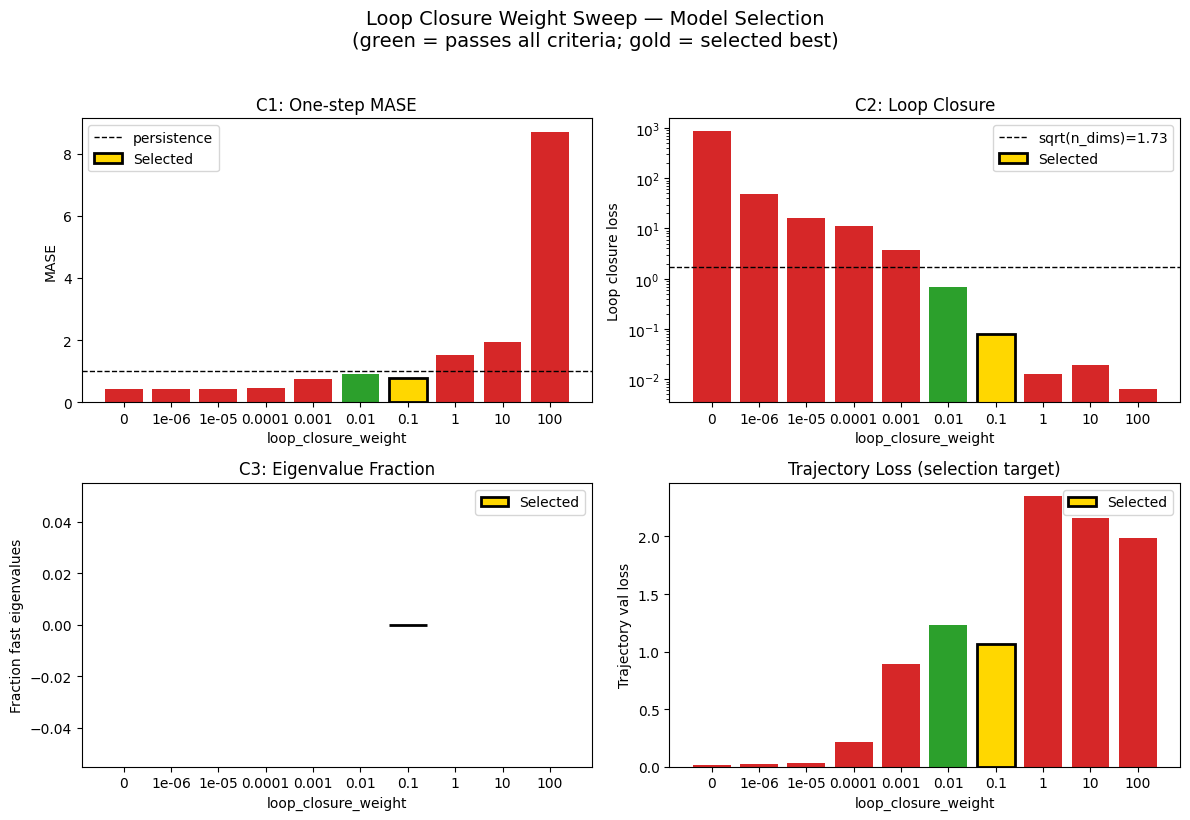

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases = [m.one_step_mase for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

colors = ['tab:green' if i in result.surviving_indices else 'tab:red'
          for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos = range(len(sweep_lambdas))

# Panel 1: One-step MASE
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
if result.best_index is not None:
    axes[0, 0].bar(result.best_index, one_step_mases[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 0].axhline(y=1.0, color='k', linestyle='--', lw=1, label='persistence')
axes[0, 0].set_xticks(x_pos); axes[0, 0].set_xticklabels(x_labels)
axes[0, 0].set_ylabel('MASE'); axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].legend()

# Panel 2: Loop closure loss
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
if result.best_index is not None:
    axes[0, 1].bar(result.best_index, loop_closure_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 1].axhline(y=np.sqrt(n_dims), color='k', linestyle='--', lw=1, label=f'sqrt(n_dims)={np.sqrt(n_dims):.2f}')
axes[0, 1].set_xticks(x_pos); axes[0, 1].set_xticklabels(x_labels)
axes[0, 1].set_ylabel('Loop closure loss'); axes[0, 1].set_title('C2: Loop Closure')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')

# Panel 3: Fast eigenvalue fraction
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
if result.best_index is not None:
    axes[1, 0].bar(result.best_index, eig_fracs[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(x_labels)
axes[1, 0].set_ylabel('Fraction fast eigenvalues'); axes[1, 0].set_title('C3: Eigenvalue Fraction')
axes[1, 0].legend()

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(x_labels)
axes[1, 1].set_ylabel('Trajectory val loss'); axes[1, 1].set_title('Trajectory Loss (selection target)')
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('loop_closure_weight')

fig.suptitle(
    'Loop Closure Weight Sweep — Model Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## 8. Load the Best Model for Downstream Use

In [36]:
best_run_id = sweep_run_ids[result.best_index]
best_lambda = sweep_lambdas[result.best_index]

# idx = 0
# best_run_id = sweep_run_ids[idx]
# best_lambda = sweep_lambdas[idx]

print(f"Loading best model: run_id={best_run_id}, lambda={best_lambda}")

run, best_cfg, eq, dt, values, _, _, _, _, best_lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# Load trained weights (load_run creates the model architecture but doesn't load checkpoint)
load_checkpoint(run, best_cfg, best_lit_model, save_dir=SAVE_DIR, verbose=True)

# Rebuild dataloaders from the loaded data
train_dl, val_dl, test_dl, trajs = create_dataloaders(best_cfg, values, verbose=True, return_full_obs=True)

print(f"\nModel type: {type(best_lit_model).__name__}")
print(f"Total params: {sum(p.numel() for p in best_lit_model.parameters()):,}")

Loading best model: run_id=c2fqgj2p, lambda=0.1
Using cached pretrained encoder.
Loading checkpoint epoch=11-step=600.ckpt...


Sequence Indices:   0%|          | 0/1155 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25410, 45, 3])
Validation dataset shape: torch.Size([8085, 45, 3])
Test dataset shape: torch.Size([3465, 45, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])

Model type: LitLatentJacobianODE
Total params: 6,786,221


### 8a. Lyapunov Exponent Comparison (Best Model)

In [37]:
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model = best_lit_model.to(device)

# --- Use full-length test trajectories for more accurate Lyapunov estimation ---
with torch.no_grad():
    # Full-length trajectories (much longer than seq_length DataLoader chunks)
    traj_full = torch.as_tensor(trajs['test_trajs'].sequence).float().to(device)
    n_test_trajs = traj_full.shape[0]
    T_full = traj_full.shape[1]
    print(f"Using {n_test_trajs} full-length test trajectories, T={T_full} each")

    z_full = best_lit_model.encode_trajectory(traj_full)  # (n_test, T, D_lat)
    print(f"Latent trajectory shape: {z_full.shape}")

    # Compute Lyapunov exponents for each trajectory individually
    all_pred_lyap = []
    for i in range(n_test_trajs):
        jacs_i = best_lit_model.compute_jacobians(z_full[i:i+1])[0]  # (T, D, D)
        le_i = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_i.cpu(), dt)
        all_pred_lyap.append(le_i)
        if i < 3:
            print(f"  Traj {i}: {le_i.numpy()}")

    all_pred_lyap = torch.stack(all_pred_lyap)  # (n_test, D)
    pred_lyap = all_pred_lyap.mean(dim=0)
    pred_lyap_std = all_pred_lyap.std(dim=0)

    # Also compute from concatenated trajectories (old method) for comparison
    test_batch = next(iter(test_dl))
    if isinstance(test_batch, (list, tuple)):
        test_batch = test_batch[0]
    test_batch = test_batch.to(device)
    z_test = best_lit_model.encode_trajectory(test_batch)
    z_short = z_test[:5].reshape(-1, z_test.shape[-1]).unsqueeze(0)
    jacs_short = best_lit_model.compute_jacobians(z_short)[0]
    pred_lyap_short = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_short.cpu(), dt)

print(f"\nPredicted Lyapunov exponents (full trajectories, mean +/- std over {n_test_trajs} trajs):")
for i, (le, std) in enumerate(zip(pred_lyap, pred_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")

print(f"\nPredicted Lyapunov exponents (short concatenated, old method):")
for i, le in enumerate(pred_lyap_short):
    print(f"  lambda_{i+1} = {le.item():+.4f}")

print(f"\nTrue Lorenz:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  lambda_{i+1} = {le:+.4f}")

# # --- Plot comparison ---
# pred_np = pred_lyap.numpy()
# pred_std_np = pred_lyap_std.numpy()
# n_pred = len(pred_np)
# n_true = len(TRUE_LYAPUNOV)
# n_plot = max(n_pred, n_true)
# x_idx = np.arange(n_plot)
# bar_w = 0.25

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.bar(x_idx[:n_pred] - bar_w, pred_np, width=bar_w,
#        label="Predicted (full traj)", alpha=0.8, yerr=pred_std_np, capsize=3)
# ax.bar(x_idx[:n_pred], pred_lyap_short.numpy(), width=bar_w,
#        label="Predicted (short concat)", alpha=0.6)
# ax.bar(x_idx[:n_true] + bar_w, TRUE_LYAPUNOV, width=bar_w,
#        label="True", alpha=0.8)
# ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
# ax.set_xticks(x_idx)
# ax.set_xlabel("Exponent index")
# ax.set_ylabel("Lyapunov exponent")
# ax.set_title(f"Lyapunov Spectrum (best lambda={best_lambda})")
# ax.legend()
# plt.tight_layout()
# plt.show()

Using 3 full-length test trajectories, T=1200 each
Latent trajectory shape: torch.Size([3, 1200, 6])
  Traj 0: [ 0.20510358  0.10000927 -0.02106865 -0.10099406 -0.18526533 -0.27193463]
  Traj 1: [ 0.20132846  0.10477118 -0.02649551 -0.10687687 -0.21811427 -0.224687  ]
  Traj 2: [ 0.2048967   0.10366852 -0.0282317  -0.10901874 -0.20073724 -0.2440513 ]

Predicted Lyapunov exponents (full trajectories, mean +/- std over 3 trajs):
  lambda_1 = +0.2038 +/- 0.0021
  lambda_2 = +0.1028 +/- 0.0025
  lambda_3 = -0.0253 +/- 0.0037
  lambda_4 = -0.1056 +/- 0.0042
  lambda_5 = -0.2014 +/- 0.0164
  lambda_6 = -0.2469 +/- 0.0238

Predicted Lyapunov exponents (short concatenated, old method):
  lambda_1 = +0.3470
  lambda_2 = +0.3217
  lambda_3 = -0.0660
  lambda_4 = -0.2930
  lambda_5 = -0.3887
  lambda_6 = -0.4300

True Lorenz:
  lambda_1 = +0.9100
  lambda_2 = +0.0000
  lambda_3 = -14.5700


### 8b. Empirical True Lyapunov Exponents (from analytical Jacobian along test trajectories)

/tmp/ipykernel_1665909/3980938842.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  traj_raw = np.array(traj_full_np) * sigma_norm + mu  # (n_traj, T, D)


Computing empirical Lyapunov exponents from analytical Jacobian
  3 trajectories, T=1200, state dim=3
  Traj 0: [  0.40232533  -0.14993943 -13.919346  ]
  Traj 1: [  0.395483    -0.22266664 -13.839784  ]
  Traj 2: [  0.35589692  -0.14227049 -13.8805895 ]

Empirical true Lyapunov exponents (mean +/- std over 3 trajs):
  lambda_1 = +0.3846 +/- 0.0251
  lambda_2 = -0.1716 +/- 0.0444
  lambda_3 = -13.8799 +/- 0.0398

Literature values:
  lambda_1 = +0.9100
  lambda_2 = +0.0000
  lambda_3 = -14.5700


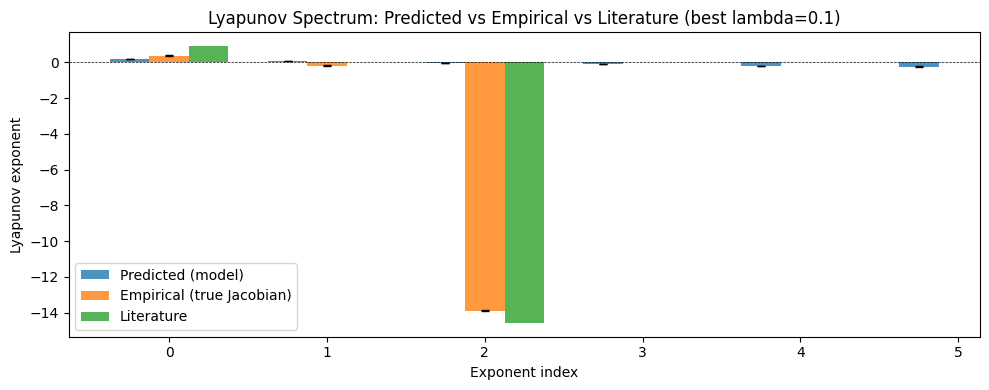

In [38]:
# --- Empirical true Lyapunov exponents from the analytical Jacobian ---
# Denormalize test trajectories to original coordinates and evaluate the
# known Jacobian of the ODE at each point along the trajectory.  Then use
# the same QR-based algorithm to get the "ground-truth" Lyapunov spectrum
# for these specific trajectories (rather than citing literature values).

mu = best_cfg.data.postprocessing.mu
sigma_norm = best_cfg.data.postprocessing.sigma

# Full-length test trajectories (normalized) — same ones used above
traj_full_np = trajs['test_trajs'].sequence  # (n_traj, T, D_obs)
n_test_trajs = traj_full_np.shape[0]
T_full = traj_full_np.shape[1]

# Denormalize to original state space
traj_raw = np.array(traj_full_np) * sigma_norm + mu  # (n_traj, T, D)

n_state = traj_raw.shape[-1]  # true state dimension
print(f"Computing empirical Lyapunov exponents from analytical Jacobian")
print(f"  {n_test_trajs} trajectories, T={T_full}, state dim={n_state}")

all_empirical_lyap = []
for i in range(n_test_trajs):
    # Compute analytical Jacobian at each time step
    jacs_np = eq.jac(traj_raw[i], t=0)  # (T, D, D)
    jacs_t = torch.as_tensor(jacs_np).float()

    le_i = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_t, dt)
    all_empirical_lyap.append(le_i)
    if i < 3:
        print(f"  Traj {i}: {le_i.numpy()}")

all_empirical_lyap = torch.stack(all_empirical_lyap)  # (n_traj, D)
empirical_lyap = all_empirical_lyap.mean(dim=0)
empirical_lyap_std = all_empirical_lyap.std(dim=0)

print(f"\nEmpirical true Lyapunov exponents (mean +/- std over {n_test_trajs} trajs):")
for i, (le, std) in enumerate(zip(empirical_lyap, empirical_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")

print(f"\nLiterature values:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  lambda_{i+1} = {le:+.4f}")

# --- Bar chart: predicted vs empirical vs literature ---
pred_np = pred_lyap.numpy()
pred_std_np = pred_lyap_std.numpy()
emp_np = empirical_lyap.numpy()
emp_std_np = empirical_lyap_std.numpy()
n_plot = max(len(pred_np), len(emp_np), len(TRUE_LYAPUNOV))
x_idx = np.arange(n_plot)
bar_w = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_idx[:len(pred_np)] - bar_w, pred_np, width=bar_w,
       yerr=pred_std_np, capsize=3, label="Predicted (model)", alpha=0.8)
ax.bar(x_idx[:len(emp_np)], emp_np, width=bar_w,
       yerr=emp_std_np, capsize=3, label="Empirical (true Jacobian)", alpha=0.8)
ax.bar(x_idx[:len(TRUE_LYAPUNOV)] + bar_w, TRUE_LYAPUNOV, width=bar_w,
       label="Literature", alpha=0.8)
ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
ax.set_xticks(x_idx)
ax.set_xlabel("Exponent index")
ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum: Predicted vs Empirical vs Literature (best lambda={best_lambda})")
ax.legend()
plt.tight_layout()
plt.show()

### 8c. Predicted Jacobian in Observation Space via Chain Rule

When `n_delays == 1` (no delay embedding), the observation **is** the true state.
We can map the model's predicted latent Jacobian back to observation space via the chain rule:

$$J_{\text{obs}}^{\text{pred}}(x_t) \approx \frac{\partial D}{\partial z}\bigg|_{z_t} \; J_{\text{latent}}^{\text{pred}}(z_t) \; \frac{\partial E}{\partial x}\bigg|_{x_t}$$

where $E$ = encoder, $D$ = decoder, and $J_{\text{latent}}^{\text{pred}}$ is the model's
predicted Jacobian in latent space. We compare the resulting observation-space Jacobian
to the true analytical ODE Jacobian (in normalized coordinates) via $R^2$.

Trajectories:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_1665909/1141971071.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x_raw = np.array(trajs['test_trajs'].sequence[traj_i]) * sigma_arr + mu_arr


  Traj 0:   0%|          | 0/100 [00:00<?, ?it/s]

  Traj 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Traj 2:   0%|          | 0/100 [00:00<?, ?it/s]


Observation-space Jacobian comparison (300 samples)
Overall R^2 (all entries): 0.1103

Per-entry R^2:
[[ 0.     0.     0.   ]
 [-1.762  0.    -1.254]
 [-0.035 -0.363  0.   ]]


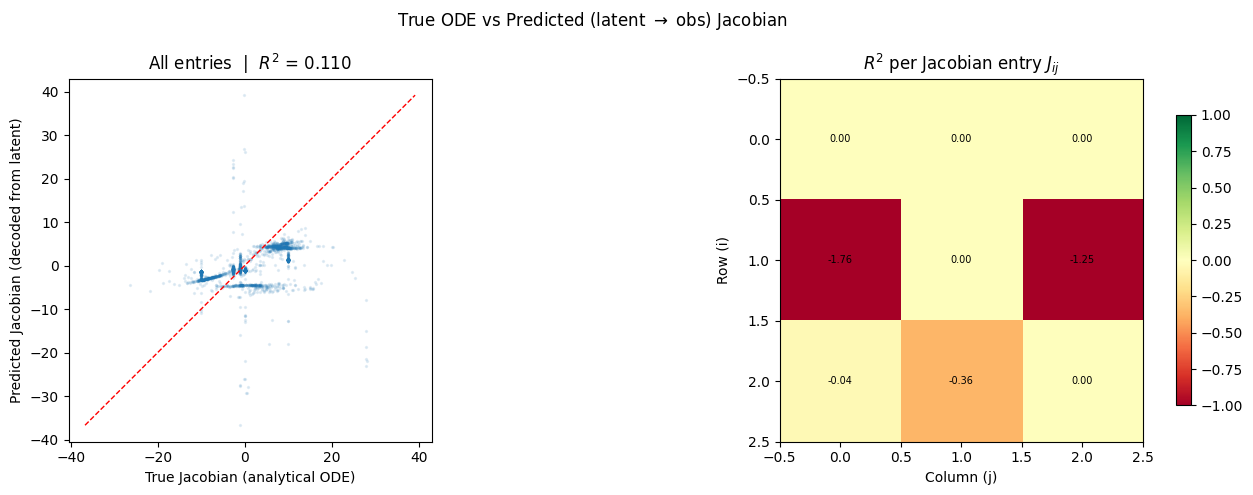

In [39]:
# --- Predicted Jacobian mapped to Observation Space via Chain Rule ---
from tqdm.auto import tqdm
from JacobianODE.jacobians.metrics import r2_score

n_delays_cfg = best_cfg.data.train_test_params.delay_embedding_params.n_delays

if n_delays_cfg != 1:
    print(f"Skipping chain-rule Jacobian comparison: n_delays={n_delays_cfg} (need 1)")
else:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    best_lit_model.eval()
    best_lit_model = best_lit_model.to(device)

    # Normalization parameters
    mu_arr = np.atleast_1d(np.array(mu))
    sigma_arr = np.atleast_1d(np.array(sigma_norm))

    # Settings
    N_TRAJS_JAC = min(3, traj_full_np.shape[0])
    N_SAMPLE_PTS = 100
    margin = getattr(best_lit_model.encoder, 'context_margin', 0)

    all_J_true = []
    all_J_pred = []

    for traj_i in tqdm(range(N_TRAJS_JAC), desc="Trajectories"):
        x_norm_t = torch.as_tensor(
            trajs['test_trajs'].sequence[traj_i:traj_i+1]
        ).float().to(device)

        # Predicted Jacobians from the model (no grad needed)
        with torch.no_grad():
            z_full = best_lit_model.encode_trajectory(x_norm_t)       # (1, T', n_latent)
            J_pred_full = best_lit_model.compute_jacobians(z_full)    # (1, T', d, d)

        T_prime = z_full.shape[1]
        n_latent = z_full.shape[2]
        n_obs = x_norm_t.shape[2]

        # Denormalized trajectory for analytical Jacobian (numpy for eq.jac)
        x_raw = np.array(trajs['test_trajs'].sequence[traj_i]) * sigma_arr + mu_arr

        # Subsample time points
        sample_idx = np.sort(
            np.random.choice(T_prime, min(N_SAMPLE_PTS, T_prime), replace=False)
        )

        for t_z in tqdm(sample_idx, desc=f"  Traj {traj_i}", leave=False):
            t_x = t_z + margin  # index in the observation sequence

            # --- 1. True ODE Jacobian in normalized coordinates ---
            J_raw = eq.jac(x_raw[t_x:t_x+1], t=0)[0]  # (n_state, n_state)
            J_raw_t = torch.tensor(J_raw, dtype=torch.float32, device=device)
            sigma_t = torch.tensor(sigma_arr, dtype=torch.float32, device=device)
            if sigma_t.numel() == 1:
                J_norm = J_raw_t
            else:
                J_norm = (1.0 / sigma_t).unsqueeze(1) * J_raw_t * sigma_t.unsqueeze(0)

            # --- 2. Encoder Jacobian  dz_t / dx_t ---
            x_inp = x_norm_t.detach().clone().requires_grad_(True)
            z_out = best_lit_model.encode_trajectory(x_inp)

            J_enc = torch.zeros(n_latent, n_obs, device=device)
            for j in range(n_latent):
                retain = (j < n_latent - 1)
                g = torch.autograd.grad(
                    z_out[0, t_z, j], x_inp, retain_graph=retain
                )[0]
                J_enc[j] = g[0, t_x]

            # --- 3. Decoder Jacobian  dx_hat / dz_t ---
            z_pt = z_full[0, t_z].detach().clone().requires_grad_(True)
            x_hat = best_lit_model.encoder.decode(z_pt.unsqueeze(0)).squeeze(0)

            J_dec = torch.zeros(n_obs, n_latent, device=device)
            for k in range(n_obs):
                retain = (k < n_obs - 1)
                g = torch.autograd.grad(x_hat[k], z_pt, retain_graph=retain)[0]
                J_dec[k] = g

            # --- 4. Chain rule: J_obs_pred = J_dec @ J_pred @ J_enc ---
            J_pred_latent = J_pred_full[0, t_z]  # (n_latent, n_latent)
            J_obs_pred = J_dec @ J_pred_latent @ J_enc  # (n_obs, n_obs)

            all_J_true.append(J_norm.detach().cpu())
            all_J_pred.append(J_obs_pred.detach().cpu())

    all_J_true = torch.stack(all_J_true)   # (N, n_obs, n_obs)
    all_J_pred = torch.stack(all_J_pred)   # (N, n_obs, n_obs)

    # --- R-squared ---
    Jt_flat = all_J_true.reshape(-1).numpy()
    Jp_flat = all_J_pred.reshape(-1).numpy()
    r2_overall = r2_score(Jt_flat, Jp_flat)

    d = all_J_true.shape[1]
    r2_matrix = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            y = all_J_true[:, i, j].numpy()
            yhat = all_J_pred[:, i, j].numpy()
            ss_t = np.sum((y - y.mean()) ** 2)
            r2_matrix[i, j] = (
                1 - np.sum((y - yhat) ** 2) / ss_t if ss_t > 1e-12 else 0.0
            )

    print(f"\nObservation-space Jacobian comparison ({len(all_J_true)} samples)")
    print(f"Overall R^2 (all entries): {r2_overall:.4f}")
    print(f"\nPer-entry R^2:")
    print(np.array2string(r2_matrix, precision=3))

    # --- Scatter plot + R^2 heatmap ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(Jt_flat, Jp_flat, alpha=0.1, s=2)
    lims = [min(Jt_flat.min(), Jp_flat.min()), max(Jt_flat.max(), Jp_flat.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel("True Jacobian (analytical ODE)")
    ax.set_ylabel("Predicted Jacobian (decoded from latent)")
    ax.set_title(f"All entries  |  $R^2$ = {r2_overall:.3f}")
    ax.set_aspect('equal')

    ax = axes[1]
    im = ax.imshow(r2_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(d):
        for j in range(d):
            ax.text(j, i, f"{r2_matrix[i, j]:.2f}",
                    ha='center', va='center', fontsize=7)
    ax.set_xlabel("Column (j)")
    ax.set_ylabel("Row (i)")
    ax.set_title("$R^2$ per Jacobian entry $J_{ij}$")

    plt.suptitle("True ODE vs Predicted (latent $\\rightarrow$ obs) Jacobian")
    plt.tight_layout()
    plt.show()

## 9. Latent Space Analysis — Participation Ratio & Embeddings

In [64]:
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model.to(device)

# ---- Encode full trajectories ----
use_train = True  # True = train set, False = test set
traj_key = "train_trajs" if use_train else "test_trajs"
full_obs_key = "train_trajs_full" if use_train else "test_trajs_full"
label_prefix = "Train" if use_train else "Test"

trajs_obs = trajs[traj_key].sequence      # (N_traj, T, D_obs)
trajs_full = trajs[full_obs_key].sequence  # (N_traj, T, D_full)

batch_traj = 8
all_latents = []
with torch.no_grad():
    for i in tqdm(range(0, trajs_obs.shape[0], batch_traj)):
        x = torch.as_tensor(trajs_obs[i : i + batch_traj]).float().to(device)
        z = best_lit_model.encode_trajectory(x)  # (B, T, n_latent)
        all_latents.append(z.cpu())
Z = torch.cat(all_latents, dim=0).numpy()  # (N_traj, T, n_latent)

# Align true state with latent length (encode_trajectory may trim)
T_latent = Z.shape[1]
trajs_full_arr = np.asarray(trajs_full)
X_true = trajs_full_arr[:, -T_latent:, :]  # align from end in case of context margin

Z_flat = Z.reshape(-1, Z.shape[-1])
X_true_flat = X_true.reshape(-1, X_true.shape[-1])

print(f"Latent shape: {Z.shape}")
print(f"True state shape: {X_true.shape}")

  0%|          | 0/3 [00:00<?, ?it/s]

Latent shape: (22, 1200, 3)
True state shape: (22, 1200, 3)


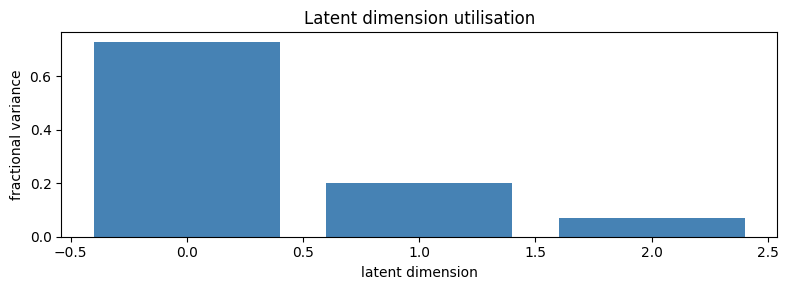

Entropy-based utilization: 0.674  (1.0 = uniform, 0.0 = single dim)


In [65]:
# ---- Per-dimension variance (latent utilisation) ----
import math

dim_var = Z_flat.var(axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dim_var)), dim_var / dim_var.sum(), color='steelblue')
ax.set_xlabel('latent dimension')
ax.set_ylabel('fractional variance')
ax.set_title('Latent dimension utilisation')
plt.tight_layout()
plt.show()

p = dim_var / dim_var.sum()
entropy = -np.sum(p * np.log(p + 1e-10))
n_latent = Z_flat.shape[-1]
utilization = entropy / math.log(n_latent)
print(f'Entropy-based utilization: {utilization:.3f}  (1.0 = uniform, 0.0 = single dim)')

Participation ratio — Latents: 1.524  |  True state (Train): 1.693


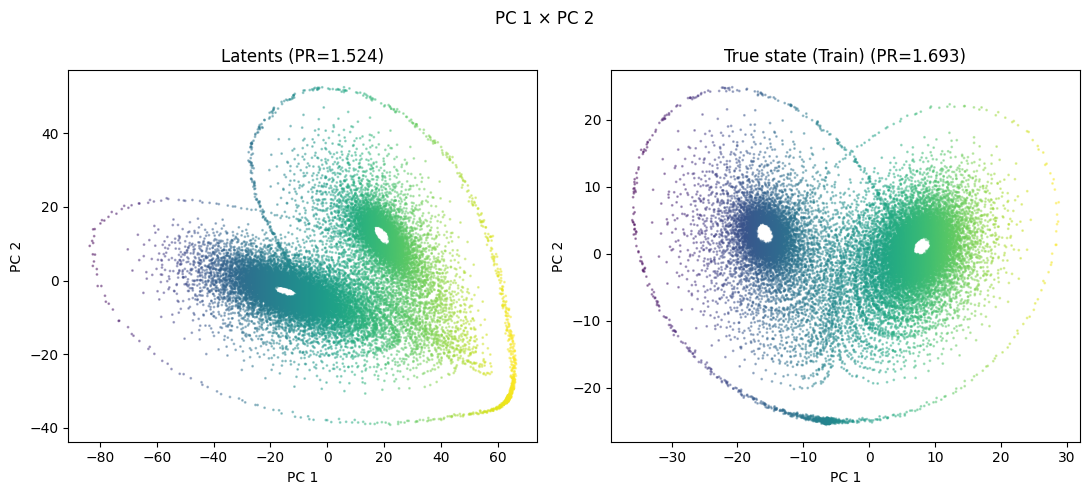

In [66]:
# ---- Participation ratio and PCA embedding plots ----
def participation_ratio(X):
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return (eigvals.sum()) ** 2 / ((eigvals**2).sum() + 1e-12)

pr_latent = participation_ratio(Z_flat)
pr_true = participation_ratio(X_true_flat)
print(f"Participation ratio — Latents: {pr_latent:.3f}  |  True state ({label_prefix}): {pr_true:.3f}")

# PCA for plotting
pca_latent = PCA(n_components=2).fit(Z_flat)
pca_true = PCA(n_components=2).fit(X_true_flat)
Z_pc = pca_latent.transform(Z_flat)
X_true_pc = pca_true.transform(X_true_flat)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(Z_pc[:, 0], Z_pc[:, 1], s=1, alpha=0.4, c=Z_pc[:, 0], cmap="viridis")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Latents (PR={pr_latent:.3f})")
axes[1].scatter(X_true_pc[:, 0], X_true_pc[:, 1], s=1, alpha=0.4, c=X_true_pc[:, 0], cmap="viridis")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].set_title(f"True state ({label_prefix}) (PR={pr_true:.3f})")
fig.suptitle("PC 1 × PC 2", fontsize=12)
plt.tight_layout()
plt.show()

Normalized FNN loss — True state:  0.061265
Normalized FNN loss — Latents:     0.050793


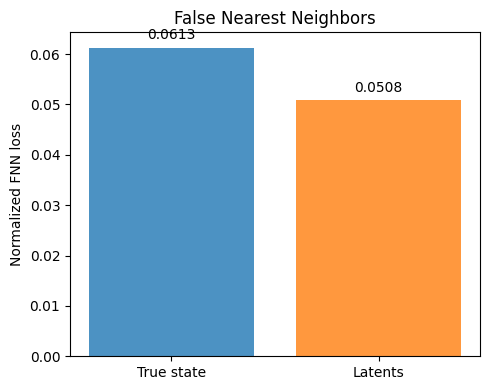

In [67]:
from JacobianODE.fnn import loss_false

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_PCA_PROJECTION = True
USE_NORMALIZE = True
ELEMENTWISE_REGULARIZATION = True

X_true_t = torch.from_numpy(X_true_flat).float().to(DEVICE)
X_latent_t = torch.from_numpy(Z_flat).float().to(DEVICE)

# Subsample for O(N^2) FNN
N_max = 2048
n = min(len(X_true_t), len(X_latent_t))
if n > N_max:
    rng = np.random.default_rng(42)
    idx = rng.choice(n, N_max, replace=False)
    X_true_t = X_true_t[idx]
    X_latent_t = X_latent_t[idx]

if USE_PCA_PROJECTION:
    X_true_np = X_true_t.detach().cpu().numpy()
    X_latent_np = X_latent_t.detach().cpu().numpy()
    pca_t = PCA(n_components=X_true_np.shape[1]).fit(X_true_np)
    pca_l = PCA(n_components=X_latent_np.shape[1]).fit(X_latent_np)
    X_true_t = torch.from_numpy(pca_t.transform(X_true_np)).float().to(DEVICE)
    X_latent_t = torch.from_numpy(pca_l.transform(X_latent_np)).float().to(DEVICE)

with torch.no_grad():
    fnn_true = loss_false(X_true_t, k=1, normalize=USE_NORMALIZE, elementwise_regularization=ELEMENTWISE_REGULARIZATION).item()
    fnn_latent = loss_false(X_latent_t, k=1, normalize=USE_NORMALIZE, elementwise_regularization=ELEMENTWISE_REGULARIZATION).item()

print(f"{'Normalized' if USE_NORMALIZE else 'Unnormalized'} FNN loss — True state:  {fnn_true:.6f}")
print(f"{'Normalized' if USE_NORMALIZE else 'Unnormalized'} FNN loss — Latents:     {fnn_latent:.6f}")

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["True state", "Latents"]
vals = [fnn_true, fnn_latent]
bars = ax.bar(labels, vals, color=["C0", "C1"], alpha=0.8)
ax.set_ylabel("Normalized FNN loss")
ax.set_title("False Nearest Neighbors")
for bar, val in zip(bars, vals):
    ax.annotate(f"{val:.4f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 10. Generated Predictions (Latent & Observation Space)

Roll out the model's built-in generation (no teacher forcing) and compare latent + observation predictions to ground truth.

Batch normalized MSE: 21.368820  (diagnostic avg: 6.264405)
Random window index:      1988 / 3255
Latent window shape:       (115, 3)
Obs prediction shape:      (100, 3)
traj_init_steps=15, prediction_steps=100


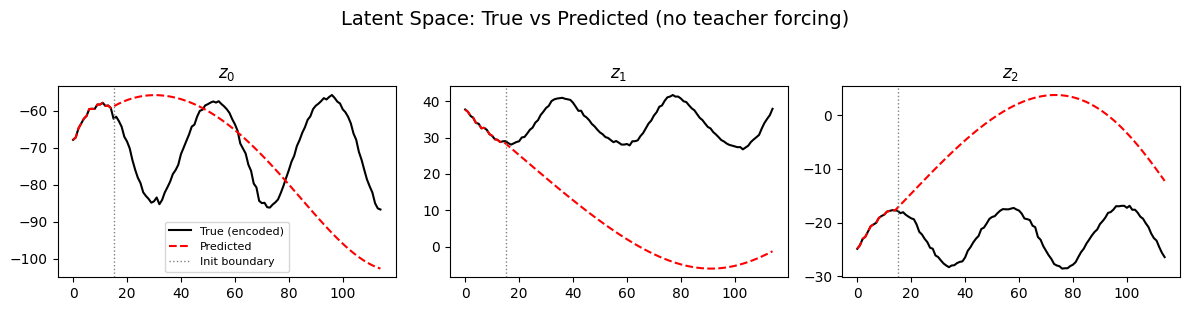

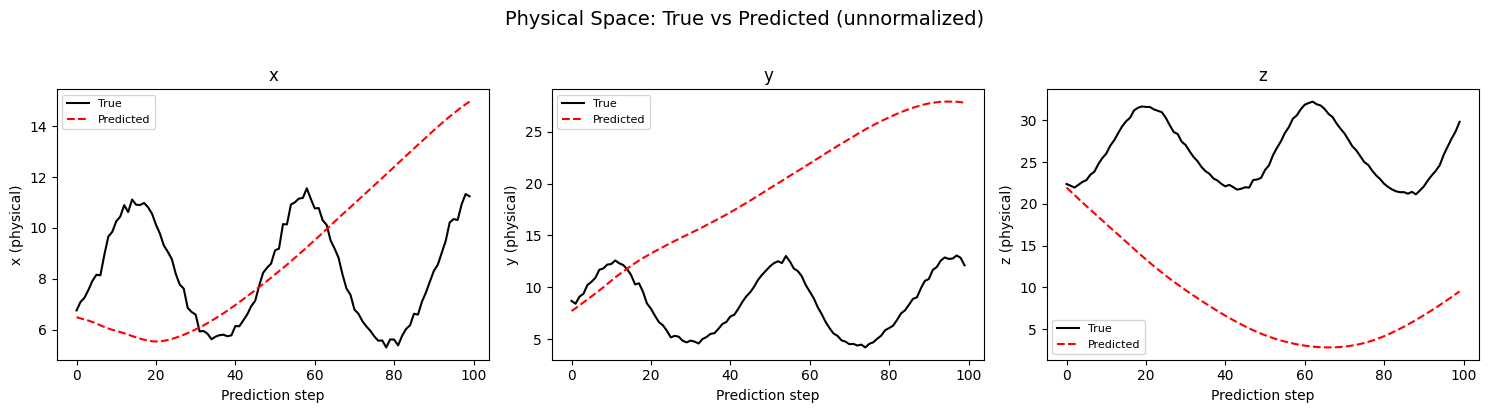

In [68]:
from JacobianODE.jacobians.metrics import normalized_mse as nmse_fn

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model = best_lit_model.to(device)

# Use trajectory data (full-length) so we can align with full-state ground truth.
# n_test = trajs['test_trajs'].sequence.shape[0]
n_test = test_dl.dataset.sequence.shape[0]
win_idx = np.random.randint(0, n_test)
# traj_obs = torch.as_tensor(trajs['test_trajs'].sequence[win_idx:win_idx+1]).float().to(device)  # (1, T_emb, 43)
traj_obs = torch.as_tensor(test_dl.dataset.sequence[win_idx:win_idx + 1]).float().to(device)

# Run trajectory prediction with NO teacher forcing
with torch.no_grad():
    result_dict = best_lit_model.trajectory_model_step(
        traj_obs,
        alpha_teacher_forcing=0.0,
        obs_noise_scale=0,
        return_decoded=True,
    )

z_pred_full = result_dict['outputs']       # (N, jac_window_len, D_latent)
decoded_pred = result_dict['decoded']       # (N, prediction_steps, D_obs)
obs_targets = result_dict['targets']        # (N, prediction_steps, D_obs)

# Print the actual loss for this batch to compare with diagnostics
batch_nmse = nmse_fn(obs_targets, decoded_pred).item()
print(f"Batch normalized MSE: {batch_nmse:.6f}  (diagnostic avg: {result.best_metrics.trajectory_val_loss:.6f})")

# Also get the true latent trajectory for comparison
with torch.no_grad():
    z_true_full = best_lit_model.encode_trajectory(traj_obs)
traj_init_steps = best_lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + best_lit_model.prediction_steps

# Use first sub-window for plotting
z_pred_win = z_pred_full[0].detach().cpu().numpy()         # (jac_window_len, D_latent)
z_true_win = z_true_full[0, :jac_window_len].detach().cpu().numpy()  # (jac_window_len, D_latent)

obs_pred_0 = decoded_pred[0].detach().cpu().numpy()         # (prediction_steps, D_obs)
obs_true_0 = obs_targets[0].detach().cpu().numpy()           # (prediction_steps, D_obs)

print(f"Random window index:      {win_idx} / {n_test}")
print(f"Latent window shape:       {z_pred_win.shape}")
print(f"Obs prediction shape:      {obs_pred_0.shape}")
print(f"traj_init_steps={traj_init_steps}, prediction_steps={best_lit_model.prediction_steps}")

# ---- Plot latent space predictions ----
n_latent = z_pred_win.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
t_steps = np.arange(jac_window_len)

for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps, z_true_win[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps, z_pred_win[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1, label='Init boundary')
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0:
        ax.legend(fontsize=8)

for i in range(n_latent, n_rows * n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)

fig.suptitle('Latent Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Plot in physical space ----
t_pred = np.arange(obs_pred_0.shape[0])
margin = getattr(best_lit_model.encoder, 'context_margin', 0)
dim_labels = ['x', 'y', 'z']

if OBSERVED_INDICES != "all" and N_DELAYS > 1:
    # Delay embedding alignment:
    # embed_signal puts most-recent at column 0, so embedded time t corresponds
    # to raw time t + (n_delays-1)*delay_spacing for the current observation.
    delay_offset = (N_DELAYS - 1) * DELAY_SPACING

    # Decoded obs dim 0 = x(t), the current observed variable (noisy)
    obs_pred_phys = obs_pred_0[:, 0] * sigma + mu
    obs_true_phys = obs_true_0[:, 0] * sigma + mu  # noisy target

    # Full-state trajectory (also noisy — noise was added before splitting)
    # Align: first predicted embedded step = traj_init_steps
    #   -> raw time = traj_init_steps + delay_offset
    test_traj_full = np.asarray(trajs['test_trajs_full'].sequence)
    pred_start_raw = margin + traj_init_steps + delay_offset
    pred_end_raw = pred_start_raw + best_lit_model.prediction_steps
    true_full_segment = test_traj_full[win_idx, pred_start_raw:pred_end_raw] * sigma + mu

    n_full = true_full_segment.shape[-1]
    fig, axes = plt.subplots(1, n_full, figsize=(5 * n_full, 4), squeeze=False)

    for d in range(n_full):
        ax = axes[0, d]
        ax.plot(t_pred, true_full_segment[:, d], 'k-', lw=1.5, label='True (noisy)')
        if d == OBSERVED_INDICES[0]:
            ax.plot(t_pred, obs_pred_phys, 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step')
        ax.set_ylabel(f'{dim_labels[d]} (physical)')
        ax.set_title(f'{dim_labels[d]}')
        ax.legend(fontsize=8)

    fig.suptitle('Physical Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    D_obs = obs_pred_0.shape[-1]
    obs_pred_phys = obs_pred_0 * sigma + mu
    obs_true_phys = obs_true_0 * sigma + mu

    fig, axes = plt.subplots(1, D_obs, figsize=(5 * D_obs, 4), squeeze=False)
    for d in range(D_obs):
        ax = axes[0, d]
        label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
        ax.plot(t_pred, obs_true_phys[:, d], 'k-', lw=1.5, label='True')
        ax.plot(t_pred, obs_pred_phys[:, d], 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step')
        ax.set_ylabel(f'{label} (physical)')
        ax.set_title(f'{label}')
        ax.legend(fontsize=8)

    fig.suptitle('Physical Space: True vs Predicted (unnormalized)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

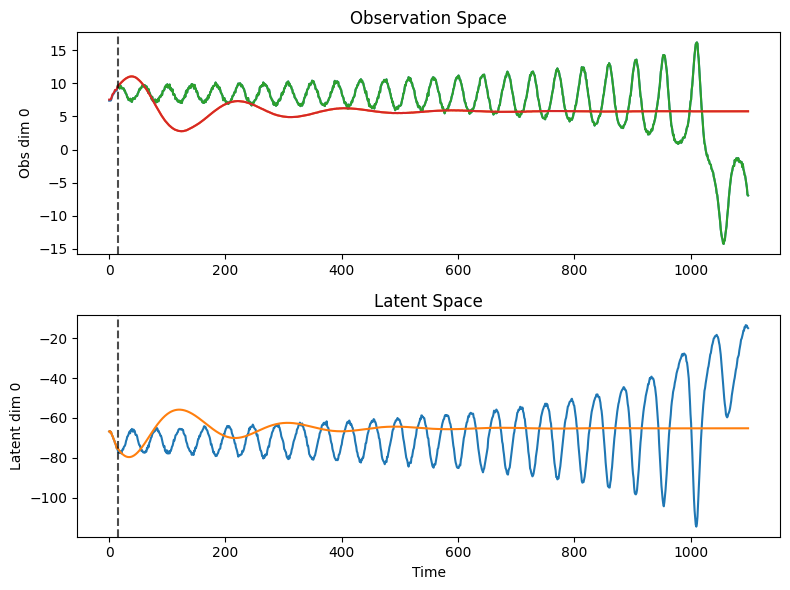

In [69]:
traj_full = trajs['test_trajs'].sequence[[0]].to(device)[:, 100:]
with torch.no_grad():
    result_dict = best_lit_model.trajectory_model_step(
        traj_full,
        alpha_teacher_forcing=0.0,
        obs_noise_scale=0,
        return_decoded=True,
        strided=False
    )

    encoded = best_lit_model.encode_trajectory(traj_full)
    recon = best_lit_model.decode_trajectory(traj_full)
    decoded_v2 = best_lit_model.decode_trajectory(result_dict['outputs'])

fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# Plot observation space (actual and predicted)
axs[0].plot(traj_full[0, :, 0].cpu(), label="True Observation")
axs[0].plot(np.arange(15, result_dict['decoded'].shape[1] + 15), result_dict['decoded'][0, :, 0].cpu(), label="Predicted Observation")
axs[0].plot(np.arange(15, result_dict['targets'].shape[1] + 15), result_dict['targets'][0, :, 0].cpu(), label="Predicted Observation")
axs[0].plot(decoded_v2[0, :, 0].cpu(), label="Predicted Observation")
axs[0].axvline(15, color='k', linestyle='--', alpha=0.7, label="Prediction Start")
axs[0].set_title("Observation Space")
axs[0].set_ylabel("Obs dim 0")
# axs[0].legend()

# Plot latent space (actual and predicted)
axs[1].plot(encoded[0, :, 0].cpu(), label="Encoded Latent")
axs[1].plot(result_dict['outputs'][0, :, 0].cpu(), label="Predicted Latent")
axs[1].axvline(15, color='k', linestyle='--', alpha=0.7, label="Prediction Start")
axs[1].set_title("Latent Space")
axs[1].set_ylabel("Latent dim 0")
axs[1].set_xlabel("Time")
# axs[1].legend()

plt.tight_layout()
plt.show()

## 11. Prediction Diagnostics — Representative Window & Per-Dimension Error

Pick a **median-loss window** (rather than window 0) to show a representative
prediction, then plot per-dimension MSE across the 43 delay-embedded columns
to see how error changes with delay history depth.

In [70]:
# ---- Collect per-window losses across multiple test trajectories ----
from JacobianODE.jacobians.metrics import normalized_mse as nmse_fn

best_lit_model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
best_lit_model = best_lit_model.to(device)

N_TEST_TRAJS = min(3, trajs['test_trajs'].sequence.shape[0])  # use all test trajs

all_decoded_pred = []  # list of (N_windows, pred_steps, D_obs)
all_obs_targets = []
all_z_pred = []
all_z_true_windows = []
all_per_window_nmse = []

traj_init_steps = best_lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + best_lit_model.prediction_steps
stride = best_lit_model.jac_window_stride

for t_idx in range(N_TEST_TRAJS):
    traj_obs_i = torch.as_tensor(
        trajs['test_trajs'].sequence[t_idx:t_idx+1]
    ).float().to(device)

    with torch.no_grad():
        rd = best_lit_model.trajectory_model_step(
            traj_obs_i,
            alpha_teacher_forcing=0.0,
            obs_noise_scale=0,
            return_decoded=True,
        )
        z_true_i = best_lit_model.encode_trajectory(traj_obs_i)  # (1, T, D_lat)

    dec_pred = rd['decoded'].cpu()   # (N, pred_steps, D_obs)
    obs_tgt = rd['targets'].cpu()    # (N, pred_steps, D_obs)
    z_pred_i = rd['outputs'].cpu()   # (N, jac_window_len, D_lat)

    # Per-window nMSE
    N_win = dec_pred.shape[0]
    mean_var = obs_tgt.reshape(-1, obs_tgt.shape[-1]).var(dim=0).mean().clamp(min=1e-8)
    for w in range(N_win):
        w_mse = (dec_pred[w] - obs_tgt[w]).pow(2).mean()
        all_per_window_nmse.append((w_mse / mean_var).item())

    # Collect z_true sub-windows matching each predicted window
    z_true_np = z_true_i[0].cpu()  # (T, D_lat)
    T_prime = z_true_np.shape[0]
    n_windows = max(1, (T_prime - jac_window_len) // stride + 1)
    for w in range(n_windows):
        start = w * stride
        if start + jac_window_len <= T_prime:
            all_z_true_windows.append(z_true_np[start:start + jac_window_len].numpy())

    all_decoded_pred.append(dec_pred.numpy())
    all_obs_targets.append(obs_tgt.numpy())
    all_z_pred.append(z_pred_i.numpy())

all_decoded_pred = np.concatenate(all_decoded_pred, axis=0)   # (total_windows, pred_steps, D_obs)
all_obs_targets = np.concatenate(all_obs_targets, axis=0)
all_z_pred = np.concatenate(all_z_pred, axis=0)               # (total_windows, jac_window_len, D_lat)
all_z_true_windows = np.array(all_z_true_windows)              # (total_windows, jac_window_len, D_lat)
all_per_window_nmse = np.array(all_per_window_nmse)

print(f"Total windows across {N_TEST_TRAJS} test trajectories: {len(all_per_window_nmse)}")
print(f"Per-window nMSE — min: {all_per_window_nmse.min():.6f}, "
      f"median: {np.median(all_per_window_nmse):.6f}, "
      f"mean: {all_per_window_nmse.mean():.6f}, "
      f"max: {all_per_window_nmse.max():.6f}")
print(f"Window 0 nMSE: {all_per_window_nmse[0]:.6f}")

Total windows across 3 test trajectories: 33
Per-window nMSE — min: 0.350601, median: 7.439146, mean: 13.889934, max: 79.725693
Window 0 nMSE: 15.473195


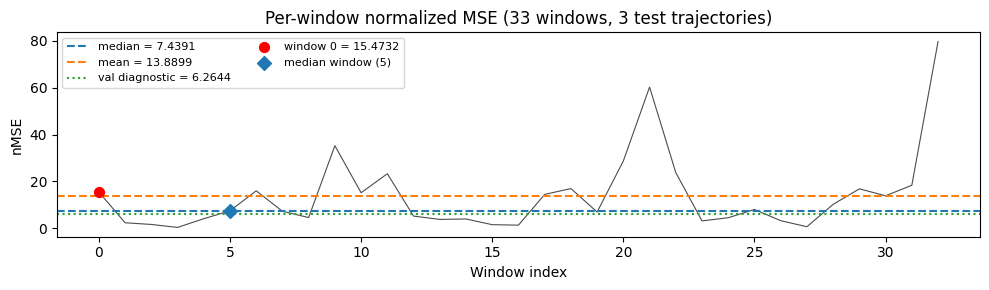

In [71]:
# ---- Plot per-window nMSE distribution ----
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(all_per_window_nmse, 'k-', lw=0.8, alpha=0.7)
ax.axhline(np.median(all_per_window_nmse), color='C0', ls='--', lw=1.5,
           label=f'median = {np.median(all_per_window_nmse):.4f}')
ax.axhline(all_per_window_nmse.mean(), color='C1', ls='--', lw=1.5,
           label=f'mean = {all_per_window_nmse.mean():.4f}')
ax.axhline(result.best_metrics.trajectory_val_loss, color='C2', ls=':', lw=1.5,
           label=f'val diagnostic = {result.best_metrics.trajectory_val_loss:.4f}')

# Mark window 0 and the median window
median_idx = np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2]
ax.scatter([0], [all_per_window_nmse[0]], c='red', s=50, zorder=5, label=f'window 0 = {all_per_window_nmse[0]:.4f}')
ax.scatter([median_idx], [all_per_window_nmse[median_idx]], c='C0', s=50, zorder=5,
           marker='D', label=f'median window ({median_idx})')

ax.set_xlabel('Window index')
ax.set_ylabel('nMSE')
ax.set_title(f'Per-window normalized MSE ({len(all_per_window_nmse)} windows, {N_TEST_TRAJS} test trajectories)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [72]:
# ---- Diagnostic: compare one-step vs free-running MASE on same test data ----
from JacobianODE.jacobians.metrics import mase

# Recompute with alpha=1 (one-step, teacher-forced) on same test trajectories
all_decoded_pred_onestep = []
all_obs_targets_onestep = []

for t_idx in range(N_TEST_TRAJS):
    traj_obs_i = torch.as_tensor(
        trajs['test_trajs'].sequence[t_idx:t_idx+1]
    ).float().to(device)
    with torch.no_grad():
        rd1 = best_lit_model.trajectory_model_step(
            traj_obs_i,
            alpha_teacher_forcing=1.0,
            obs_noise_scale=0,
            return_decoded=True,
        )
    all_decoded_pred_onestep.append(rd1['decoded'].cpu().numpy())
    all_obs_targets_onestep.append(rd1['targets'].cpu().numpy())

all_decoded_pred_onestep = np.concatenate(all_decoded_pred_onestep, axis=0)
all_obs_targets_onestep = np.concatenate(all_obs_targets_onestep, axis=0)

# Compute MASE for both modes on the SAME test windows
mase_freerun = mase(all_obs_targets, all_decoded_pred)
mase_onestep = mase(all_obs_targets_onestep, all_decoded_pred_onestep)

# Also compute per-window MASE for distributions
mase_per_window_freerun = []
mase_per_window_onestep = []
for w in range(all_obs_targets.shape[0]):
    mase_per_window_freerun.append(mase(all_obs_targets[w], all_decoded_pred[w]))
    mase_per_window_onestep.append(mase(all_obs_targets_onestep[w], all_decoded_pred_onestep[w]))
mase_per_window_freerun = np.array(mase_per_window_freerun)
mase_per_window_onestep = np.array(mase_per_window_onestep)

# Also compute persistence MAE and model MAE for sanity check
persistence_mae = np.mean(np.abs(all_obs_targets[:, 1:] - all_obs_targets[:, :-1]))
model_mae_freerun = np.mean(np.abs(all_obs_targets - all_decoded_pred))
model_mae_onestep = np.mean(np.abs(all_obs_targets_onestep - all_decoded_pred_onestep))

print("=" * 60)
print("DIAGNOSTIC: One-step vs Free-running MASE (same test data)")
print("=" * 60)
print(f"  Persistence MAE (denominator):  {persistence_mae:.6f}")
print(f"  Model MAE (one-step, alpha=1):  {model_mae_onestep:.6f}")
print(f"  Model MAE (free-run, alpha=0):  {model_mae_freerun:.6f}")
print(f"  MASE (one-step, alpha=1):       {mase_onestep:.4f}")
print(f"  MASE (free-run, alpha=0):       {mase_freerun:.4f}")
print()
print(f"  Per-window MASE (one-step) — mean: {mase_per_window_onestep.mean():.4f}, "
      f"median: {np.median(mase_per_window_onestep):.4f}")
print(f"  Per-window MASE (free-run) — mean: {mase_per_window_freerun.mean():.4f}, "
      f"median: {np.median(mase_per_window_freerun):.4f}")
print()
if mase_onestep > mase_freerun:
    print("  ⚠ BUG CONFIRMED: one-step MASE > free-running MASE on same data!")
    print("    One-step predictions should ALWAYS be at least as good as free-running.")
else:
    print("  ✓ One-step ≤ free-running (expected). Bar chart discrepancy is likely")
    print("    due to val vs test data or cached stale diagnostics.")

DIAGNOSTIC: One-step vs Free-running MASE (same test data)
  Persistence MAE (denominator):  0.444449
  Model MAE (one-step, alpha=1):  0.366838
  Model MAE (free-run, alpha=0):  11.670034
  MASE (one-step, alpha=1):       0.8254
  MASE (free-run, alpha=0):       26.2573

  Per-window MASE (one-step) — mean: 0.8299, median: 0.7968
  Per-window MASE (free-run) — mean: 26.1795, median: 27.1137

  ✓ One-step ≤ free-running (expected). Bar chart discrepancy is likely
    due to val vs test data or cached stale diagnostics.


Plotting median-loss window: index=5, nMSE=7.439146
(Compare to window 0 nMSE=15.473195)
Median window MASE (normalized): 29.7123
Median window MASE (physical):   29.7123
  Model MAE (physical):      10.1107
  Persistence MAE (physical): 0.3403


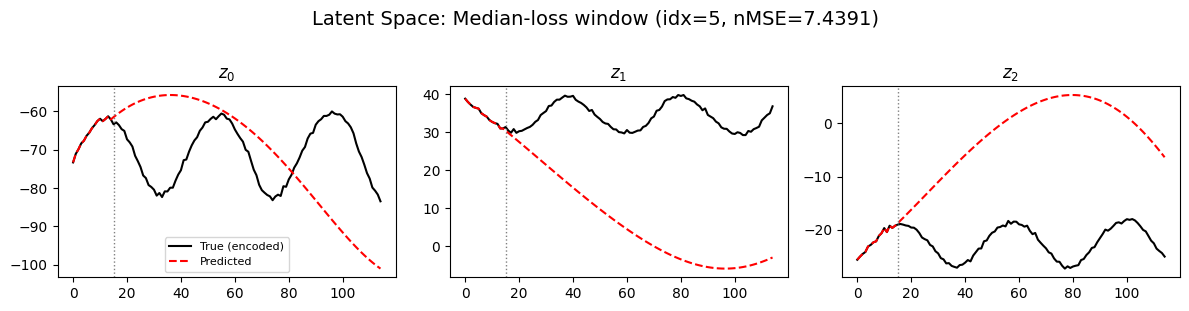

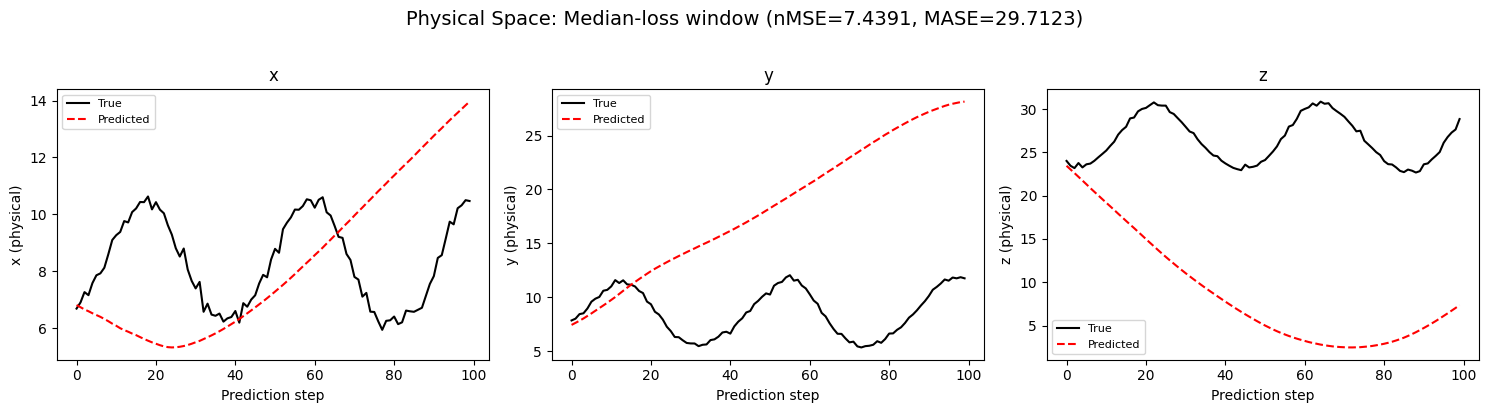

In [73]:
# ---- Representative (median-loss) window: latent + physical space ----
median_idx = int(np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2])
print(f"Plotting median-loss window: index={median_idx}, nMSE={all_per_window_nmse[median_idx]:.6f}")
print(f"(Compare to window 0 nMSE={all_per_window_nmse[0]:.6f})")

z_pred_med = all_z_pred[median_idx]                # (jac_window_len, D_lat)
z_true_med = all_z_true_windows[median_idx]         # (jac_window_len, D_lat)
obs_pred_med = all_decoded_pred[median_idx]          # (pred_steps, D_obs)
obs_true_med = all_obs_targets[median_idx]            # (pred_steps, D_obs)

# ---- Compute MASE for this window (normalized space) ----
from JacobianODE.jacobians.metrics import mase
window_mase_norm = mase(obs_true_med, obs_pred_med)
# Also compute in physical space
obs_pred_phys_all = obs_pred_med * sigma + mu
obs_true_phys_all = obs_true_med * sigma + mu
window_mase_phys = mase(obs_true_phys_all, obs_pred_phys_all)
persistence_mae = np.mean(np.abs(obs_true_phys_all[1:] - obs_true_phys_all[:-1]))
model_mae = np.mean(np.abs(obs_true_phys_all - obs_pred_phys_all))
print(f"Median window MASE (normalized): {window_mase_norm:.4f}")
print(f"Median window MASE (physical):   {window_mase_phys:.4f}")
print(f"  Model MAE (physical):      {model_mae:.4f}")
print(f"  Persistence MAE (physical): {persistence_mae:.4f}")

# ---- Latent space ----
n_latent = z_pred_med.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols
t_steps = np.arange(jac_window_len)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)
for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps, z_true_med[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps, z_pred_med[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1)
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0:
        ax.legend(fontsize=8)
for i in range(n_latent, n_rows * n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)
fig.suptitle(f'Latent Space: Median-loss window (idx={median_idx}, nMSE={all_per_window_nmse[median_idx]:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Physical space ----
t_pred = np.arange(obs_pred_med.shape[0])
dim_labels = ['x', 'y', 'z']

if OBSERVED_INDICES != "all" and N_DELAYS > 1:
    obs_pred_phys_med = obs_pred_med[:, 0] * sigma + mu
    obs_true_phys_med = obs_true_med[:, 0] * sigma + mu

    # Find which test trajectory and local window this median_idx belongs to
    # (windows are concatenated across trajectories)
    T_prime = trajs['test_trajs'].sequence.shape[1]
    n_win_per_traj = max(1, (T_prime - jac_window_len) // stride + 1)
    traj_idx_med = median_idx // n_win_per_traj
    local_win_med = median_idx % n_win_per_traj

    delay_offset = (N_DELAYS - 1) * DELAY_SPACING
    margin = getattr(best_lit_model.encoder, 'context_margin', 0)
    win_start = local_win_med * stride
    pred_start_raw = margin + win_start + traj_init_steps + delay_offset
    pred_end_raw = pred_start_raw + best_lit_model.prediction_steps

    test_traj_full = np.asarray(trajs['test_trajs_full'].sequence)
    true_full_seg = test_traj_full[traj_idx_med, pred_start_raw:pred_end_raw] * sigma + mu

    n_full = true_full_seg.shape[-1]
    fig, axes_phys = plt.subplots(1, n_full, figsize=(5 * n_full, 4), squeeze=False)
    for d in range(n_full):
        ax = axes_phys[0, d]
        ax.plot(t_pred, true_full_seg[:, d], 'k-', lw=1.5, label='True (noisy)')
        if d == OBSERVED_INDICES[0]:
            ax.plot(t_pred, obs_pred_phys_med, 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step')
        ax.set_ylabel(f'{dim_labels[d]} (physical)')
        ax.set_title(f'{dim_labels[d]}')
        ax.legend(fontsize=8)
    fig.suptitle(f'Physical Space: Median-loss window (idx={median_idx}, nMSE={all_per_window_nmse[median_idx]:.4f}, MASE={window_mase_phys:.4f})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    obs_pred_phys_med = obs_pred_med * sigma + mu
    obs_true_phys_med = obs_true_med * sigma + mu
    D_obs = obs_pred_med.shape[-1]
    fig, axes_phys = plt.subplots(1, D_obs, figsize=(5 * D_obs, 4), squeeze=False)
    for d in range(D_obs):
        ax = axes_phys[0, d]
        label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
        ax.plot(t_pred, obs_true_phys_med[:, d], 'k-', lw=1.5, label='True')
        ax.plot(t_pred, obs_pred_phys_med[:, d], 'r--', lw=1.5, label='Predicted')
        ax.set_xlabel('Prediction step'); ax.set_ylabel(f'{label} (physical)'); ax.set_title(label)
        ax.legend(fontsize=8)
    fig.suptitle(f'Physical Space: Median-loss window (nMSE={all_per_window_nmse[median_idx]:.4f}, MASE={window_mase_phys:.4f})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

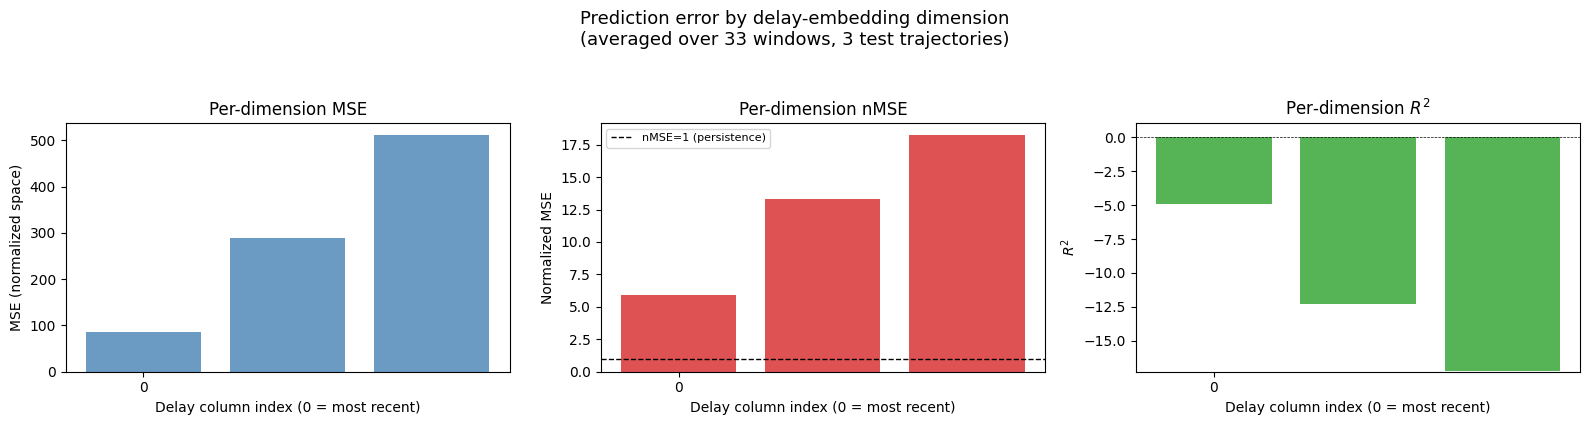

 Dim    Lag (dt)         MSE        nMSE          R²   Var(true)
--------------------------------------------------------------
   0      0.0000   85.316864    5.885111     -4.8851   14.497069
   1      0.0150  289.373810   13.278891    -12.2789   21.792017
   2      0.0300  511.213776   18.235754    -17.2358   28.033598

Overall nMSE (mean across dims): 12.466586
Dim 0 (current x) nMSE:          5.885111
Dim 2 (oldest delay) nMSE:       18.235754


In [74]:
# ---- Per-dimension MSE across the 43 delay-embedded columns ----
# Columns: dim 0 = x(t) (most recent), dim 1 = x(t - delay_spacing), ..., dim 42 = x(t - 42*delay_spacing)
# This shows how prediction error changes with delay history depth.

# MSE per dimension, averaged across all windows and prediction steps
# all_decoded_pred: (total_windows, pred_steps, D_obs=43)
# all_obs_targets:  (total_windows, pred_steps, D_obs=43)
per_dim_mse = ((all_decoded_pred - all_obs_targets) ** 2).mean(axis=(0, 1))  # (D_obs,)
per_dim_var = all_obs_targets.reshape(-1, all_obs_targets.shape[-1]).var(axis=0)  # (D_obs,)
per_dim_nmse = per_dim_mse / np.clip(per_dim_var, 1e-8, None)

# Also compute per-dimension R^2
per_dim_r2 = 1.0 - per_dim_nmse

# X-axis: delay index → physical time lag
delay_lags = np.arange(all_obs_targets.shape[-1]) * DELAY_SPACING * dt  # in time units

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Raw MSE per dimension
ax = axes[0]
ax.bar(range(len(per_dim_mse)), per_dim_mse, color='steelblue', alpha=0.8)
ax.set_xlabel('Delay column index (0 = most recent)')
ax.set_ylabel('MSE (normalized space)')
ax.set_title('Per-dimension MSE')
ax.set_xticks(range(0, len(per_dim_mse), 5))

# Panel 2: Normalized MSE per dimension
ax = axes[1]
colors = ['C3' if v > 0.1 else 'C1' if v > 0.01 else 'C0' for v in per_dim_nmse]
ax.bar(range(len(per_dim_nmse)), per_dim_nmse, color=colors, alpha=0.8)
ax.axhline(1.0, color='k', ls='--', lw=1, label='nMSE=1 (persistence)')
ax.set_xlabel('Delay column index (0 = most recent)')
ax.set_ylabel('Normalized MSE')
ax.set_title('Per-dimension nMSE')
ax.set_xticks(range(0, len(per_dim_nmse), 5))
ax.legend(fontsize=8)

# Panel 3: R^2 per dimension
ax = axes[2]
ax.bar(range(len(per_dim_r2)), per_dim_r2, color='C2', alpha=0.8)
ax.axhline(0.0, color='k', ls='--', lw=0.5)
ax.set_xlabel('Delay column index (0 = most recent)')
ax.set_ylabel('$R^2$')
ax.set_title('Per-dimension $R^2$')
ax.set_xticks(range(0, len(per_dim_r2), 5))
ax.set_ylim(min(0, per_dim_r2.min() - 0.05), 1.05)

fig.suptitle(
    f'Prediction error by delay-embedding dimension\n'
    f'(averaged over {len(all_per_window_nmse)} windows, {N_TEST_TRAJS} test trajectories)',
    fontsize=13, y=1.05,
)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Dim':>4s}  {'Lag (dt)':>10s}  {'MSE':>10s}  {'nMSE':>10s}  {'R²':>10s}  {'Var(true)':>10s}")
print("-" * 62)
for d in range(len(per_dim_mse)):
    lag_str = f"{d * DELAY_SPACING * dt:.4f}"
    print(f"{d:4d}  {lag_str:>10s}  {per_dim_mse[d]:10.6f}  {per_dim_nmse[d]:10.6f}  {per_dim_r2[d]:10.4f}  {per_dim_var[d]:10.6f}")

print(f"\nOverall nMSE (mean across dims): {per_dim_nmse.mean():.6f}")
print(f"Dim 0 (current x) nMSE:          {per_dim_nmse[0]:.6f}")
print(f"Dim {len(per_dim_nmse) - 1} (oldest delay) nMSE:       {per_dim_nmse[-1]:.6f}")

## 12. Export HTML of this Notebook

In [75]:
import subprocess
# cmd = "uv run jupyter nbconvert --to html --output '2026-03-08_Pretrained Encoder + JacobianODE (Lorenz - hyperparameter sweep)' '_jupyter/Pretrained Encoder + JacobianODE (Lorenz - hyperparameter sweep).ipynb'"
cmd = "uv run jupyter nbconvert --to html --output '2026-03-09 - Lorenz Full State Normalized P100' '/home/eisenaj/code/JacobianODE/_jupyter/Pretrained Encoder + JacobianODE (Lorenz - hyperparameter sweep).ipynb'"
subprocess.run(cmd, shell=True)

[NbConvertApp] Converting notebook /home/eisenaj/code/JacobianODE/_jupyter/Pretrained Encoder + JacobianODE (Lorenz - hyperparameter sweep).ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('id' was unexpected)

Failed validating 'additionalProperties' in markdown_cell:

On instance['cells'][0]:
{'cell_type': 'markdown',
 'id': 'cell-0',
 'metadata': {},
 'source': '# Pre-trained Encoder + JacobianODE — Lorenz (Loop Closure '
           'Sweep...'}
[NbConvertApp] WARNING | Alternative text is missing on 12 image(s).
[NbConvertApp] Writing 1938536 bytes to /home/eisenaj/code/JacobianODE/_jupyter/2026-03-09 - Lorenz Full State Normalized P100.html


CompletedProcess(args="uv run jupyter nbconvert --to html --output '2026-03-09 - Lorenz Full State Normalized P100' '/home/eisenaj/code/JacobianODE/_jupyter/Pretrained Encoder + JacobianODE (Lorenz - hyperparameter sweep).ipynb'", returncode=0)